# Heatwave Detection on ERA5, MeteoChile and Historical CMIP6

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd
import xarray as xr


# Add the folder to the Python path

os.chdir("../")
# change working directory to project's root path
print(os.getcwd())

folder_path = os.path.abspath("functions/") #INPUT_PATH)#'path_to_your_folder')  # Replace with the actual folder path
sys.path.insert(0, folder_path)

c:\Users\marti\Desktop\data\hw_extra


In [3]:
from indices import get_heatwaves_indices, transform_time_label

## Load data

In [5]:
hws_chile = pd.read_csv("data/local_data/monthly/hws_chile_new_agg.csv")

hws_chile["time"] = pd.to_datetime(hws_chile["Unnamed: 0"],format='%Y-%m')
hws_chile.set_index('time', inplace=True)
hws_chile.drop(columns="Unnamed: 0", inplace=True)
# hws_chile = hws_chile[["hwn", "hwf", "hwd", "hwm", "hwa", "hwmeani"]]
hws_chile

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,
1971-01-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...
2024-08-01,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


In [8]:
path_stations_detection = "data/03_primary/events/cmip6/"
# scenarios = ['historical']
cmip6_models = ['MPI-ESM1-2-HR', 'MRI-ESM2-0', 'GFDL-ESM4', 'EC-Earth3', 'MIROC6', 'AWI-CM-1-1-MR', 'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-LR', 'ACCESS-ESM1-5', 'IPSL-CM6A-LR']
stat_list = [
    "330007",
    "330020",
    "330030",
    "340031",
    "360011",
    "360019",
    "380013",
    "390006",
    "400009",
    "410005",
]
hw_model_scenario_station_df = {
    model: {
            station: xr.open_dataset(f"{path_stations_detection}/{model}/historical/station_detection/{station}/default.nc").to_dataframe() for station in stat_list
    } for model in cmip6_models
}

In [9]:
path_stations_detection = "data/03_primary/events/era5/"
hws_era5_df ={
            station: xr.open_dataset(f"{path_stations_detection}/station_detection/{station}/default.nc").to_dataframe() for station in stat_list
        } 
hw_model_scenario_station_df["ERA5"] = hws_era5_df

In [11]:
hws_chile_model_scenario_yearly = {}
indices_of_interest = ("hwn", "hwf", "hwd", "hwm", "hwa", "hwmeand", "hwi", "hwmaxi", "hwmeani")
for model_name, dict_stations in hw_model_scenario_station_df.items():
    stations_indices = {}
    target_years = (1970, 2014)

    # Get yearly indices for 10 stations
    for station_name, hw in dict_stations.items():
        stations_indices[station_name] = get_heatwaves_indices(hw, target_years, time_scale="year")
        stations_indices[station_name].index = pd.DatetimeIndex(stations_indices[station_name].index)

    # Concat stations indices
    hws_all_stats = pd.concat(list(stations_indices.values()), axis=1)
    hws_chile_df = pd.DataFrame(columns=indices_of_interest, index=hws_all_stats.index)

    for index in indices_of_interest:
        if index in ["hwn", "hwf", "hwi"]:
            hws_chile_df[index] = hws_all_stats[index].mean(axis=1)
        elif index in ["hwd", "hwa", "hwmaxi"]:
            hws_chile_df[index] = hws_all_stats[index].max(axis=1)
        elif index == "hwmeand":
            hws_chile_df[index] = hws_all_stats["hwf"].sum(axis=1) / hws_all_stats["hwn"].sum(axis=1)
        elif index == "hwm":
            hws_chile_df[index] = hws_all_stats["hwi"].sum(axis=1) / hws_all_stats["hwf"].sum(axis=1)
        elif index == "hwmeani":
            hws_chile_df[index] = hws_all_stats["hwi"].sum(axis=1) / hws_all_stats["hwn"].sum(axis=1)

    hws_chile_df = hws_chile_df.fillna(0.0)
    hws_chile_model_scenario_yearly[model_name] = hws_chile_df

In [13]:
meteochile_yearly = transform_time_label(hws_chile, "year")
hws_chile_model_scenario_yearly.update({"meteochile": meteochile_yearly})

In [24]:
dfs_yearly = {}
for index in indices_of_interest:
    df_index = pd.DataFrame()
    for model_name, df in hws_chile_model_scenario_yearly.items():
        df_index[model_name] = df[index]
    dfs_yearly[index] = df_index

    # Average indices across all models to create ensemble
    dfs_yearly[index]["ensemble_mean"] = (
        dfs_yearly[index].drop(columns=["meteochile", "ERA5"]).mean(axis=1)
    )
    dfs_yearly[index]["ensemble_std"] = (
        dfs_yearly[index].drop(columns=["meteochile", "ERA5"]).std(axis=1)
    )
dfs_yearly["hwn"]

,MPI-ESM1-2-HR,MRI-ESM2-0,GFDL-ESM4,EC-Earth3,MIROC6,AWI-CM-1-1-MR,INM-CM4-8,INM-CM5-0,MPI-ESM1-2-LR,ACCESS-ESM1-5,IPSL-CM6A-LR,ERA5,meteochile,ensemble_mean,ensemble_std
1970-01-01,8.2,4.1,1.4,2.8,3.0,5.0,6.4,4.5,7.4,6.0,5.2,3.2,NaN,4.909091,1.948638
1971-01-01,3.6,4.9,4.6,2.8,2.6,2.3,7.8,4.6,6.6,4.8,3.9,2.0,1.1,4.409091,1.595137
1972-01-01,4.5,5.6,3.7,2.1,6.1,3.7,3.6,5.5,6.9,3.6,6.7,3.0,2.1,4.727273,1.460443
1973-01-01,3.8,5.1,3.1,3.6,4.4,2.8,5.9,4.1,6.7,4.5,3.9,1.9,1.2,4.354545,1.112216
1974-01-01,2.5,5.3,2.8,3.0,3.2,2.7,6.8,8.9,5.2,1.4,5.0,2.6,1.9,4.254545,2.111597
1975-01-01,6.9,4.4,2.7,5.5,3.8,3.8,4.8,6.2,6.3,3.7,4.1,1.3,0.7,4.745455,1.255796
1976-01-01,5.7,1.6,2.0,4.0,2.2,4.5,6.5,4.1,2.4,4.8,5.5,3.0,1.5,3.936364,1.589896
1977-01-01,5.6,4.5,5.0,4.6,3.3,2.8,8.0,8.1,3.2,4.5,6.3,5.8,4.7,5.081818,1.711362
1978-01-01,10.7,8.3,4.1,5.6,3.9,3.0,8.5,5.9,0.6,3.4,5.8,4.0,3.5,5.436364,2.751619
1979-01-01,7.6,4.3,3.5,3.4,4.1,4.6,7.9,5.4,6.0,6.8,2.3,4.3,3.5,5.081818,1.733529


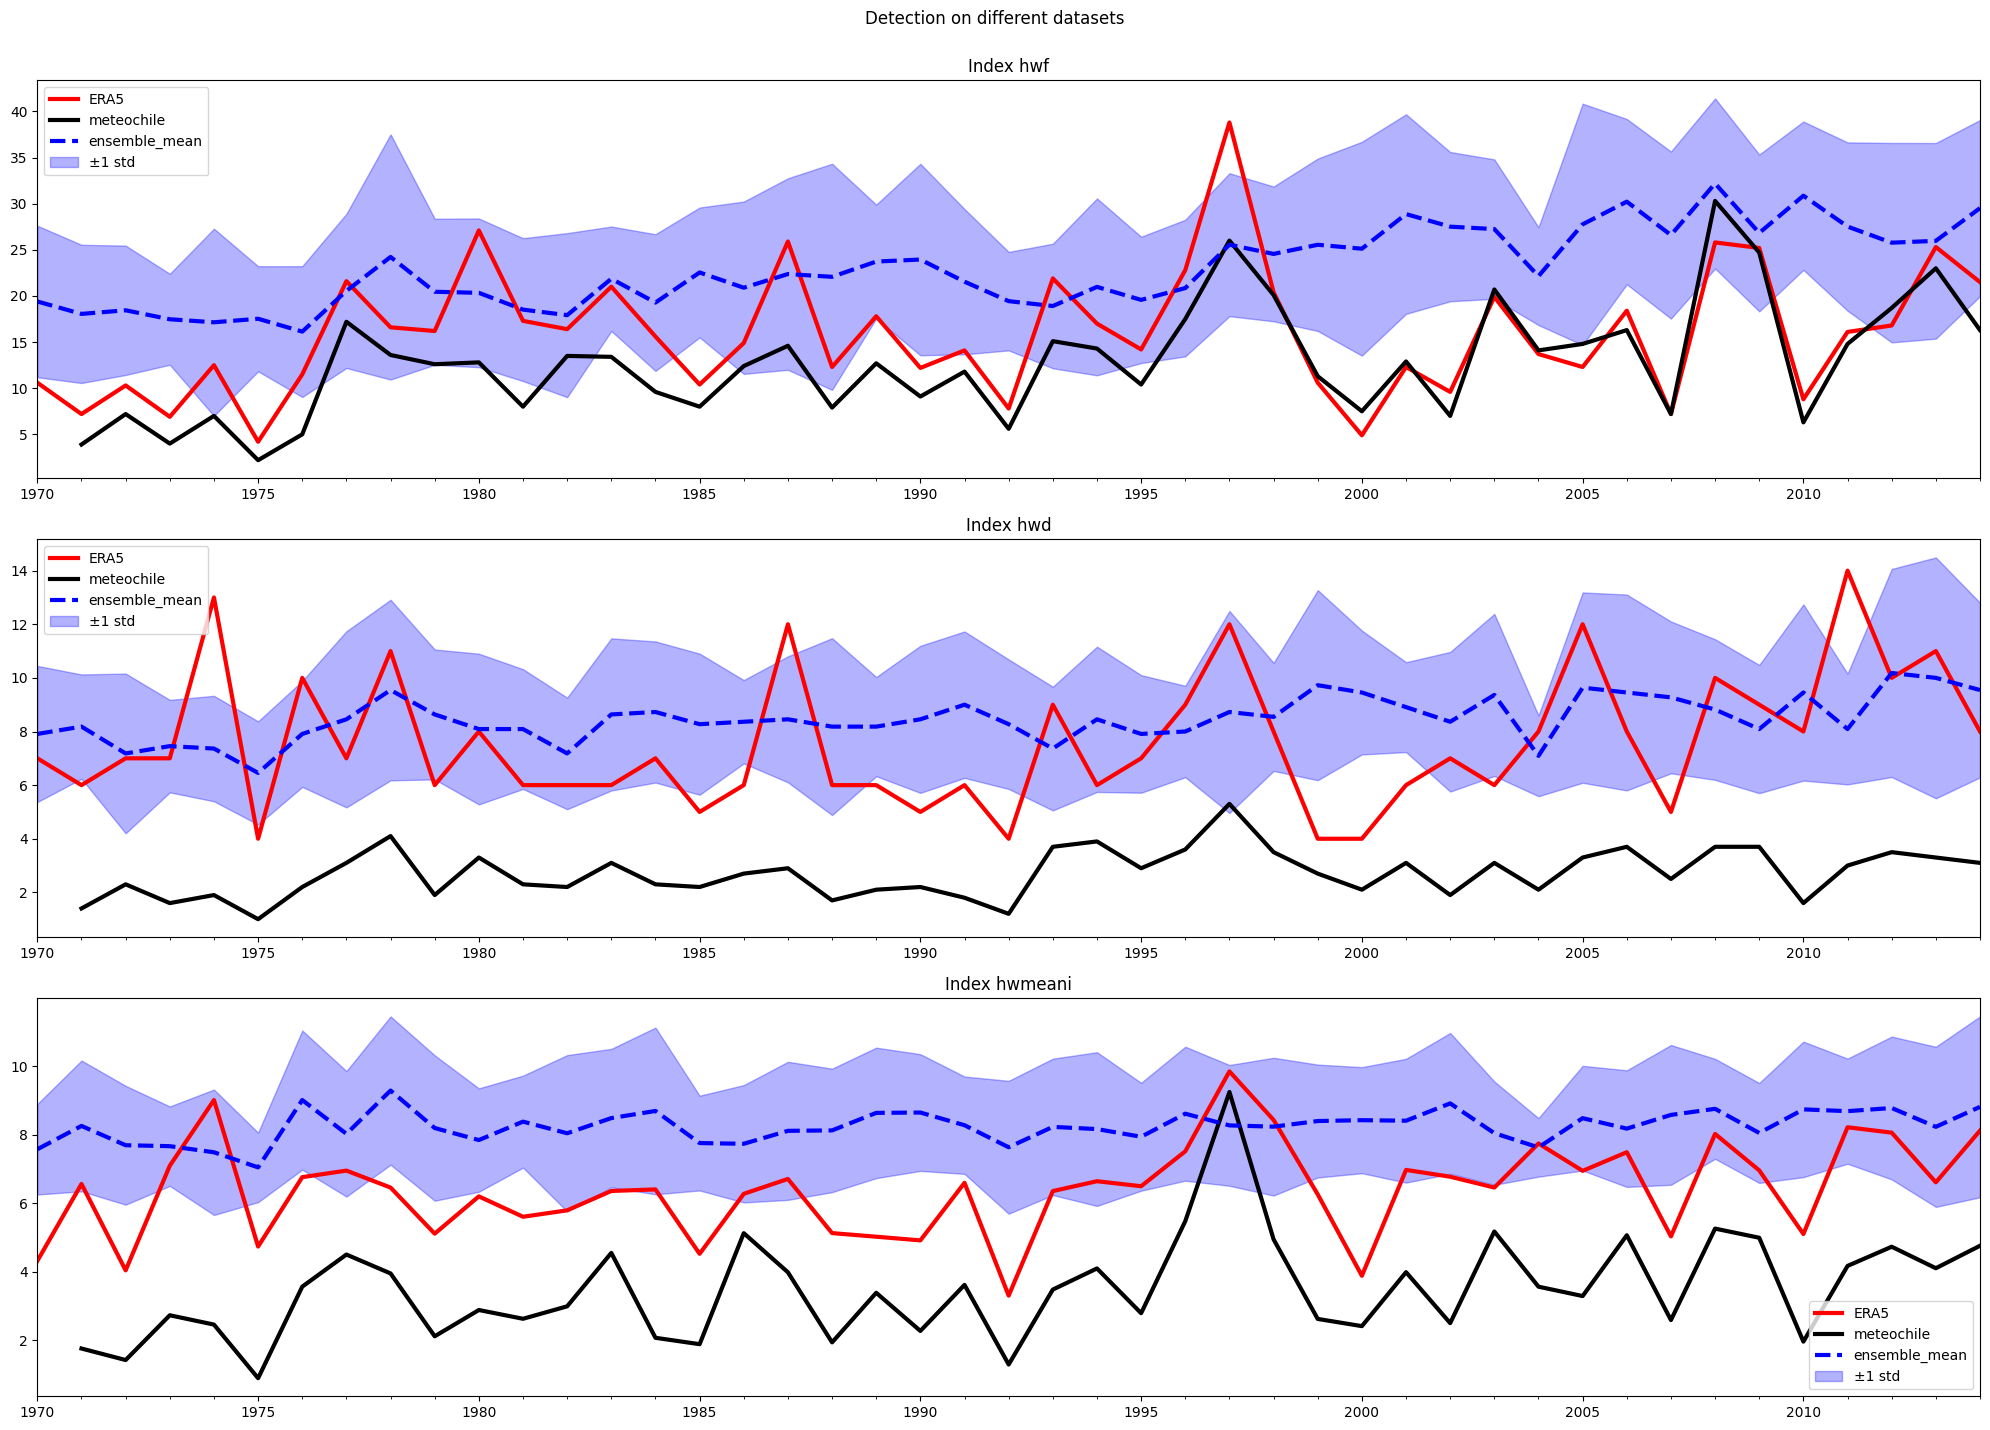

In [29]:
fig, axs = plt.subplots(3, figsize=(20, 15))
for i, index in enumerate(["hwf", "hwd", "hwmeani"]):
    for model_name in dfs_yearly[index].columns:
        if model_name == "meteochile":
            dfs_yearly[index].plot(y=model_name, ax=axs[i], lw=3, c="black")
        elif model_name == "ERA5":
            dfs_yearly[index].plot(y=model_name, ax=axs[i], lw=3, c="red")
        elif model_name == "ensemble_mean":
            dfs_yearly[index].plot(y=model_name, ax=axs[i], lw=3, c="blue", linestyle="--")
    dates = dfs_yearly[index].index
    values = dfs_yearly[index]["ensemble_mean"]
    std_values = dfs_yearly[index]["ensemble_std"]
    axs[i].fill_between(
        dates, values - std_values, values + std_values, alpha=0.3, color="blue", label="±1 std"
    )
    axs[i].set_title(f"Index {index}")
    axs[i].legend()
fig.suptitle(f"Detection on different datasets")
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()